In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Jokainen on ladannut datasetin koneelle, mutta koska se on yli 100mb niin ei saada gittiin vaan tehdään suoraan yhteinen "karsittu" datasetti joka kulkee yhteisessä. Tässä koodi jolla luotiin yhteinen "karsittu_100k_sample.csv"


df100k = df.sample(n=100000, random_state=42)
 
Valitut10 =[
'Init_Win_bytes_forward',
'Flow IAT Mean',
'Packet Length Std',
'Subflow Fwd Bytes',
'Flow Duration',
'Bwd Packet Length Mean',
'Total Length of Fwd Packets',
'PSH Flag Count',
'Flow Packets/s',
'Destination Port',
'Attack Type'
]

df_valitut = df100k[Valitut10]
print(df_valitut.head())

df_valitut.to_csv('karsittu_100k_sample.csv', index=False)

In [9]:
df_raw = pd.read_csv("karsittu_100k_sample.csv")

X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Koulutetaan Random Forest -mallia (tässä saattaa mennä hetki)...

LOPULLISET TULOKSET (Random Forest) - TESTIDATA

LOPULLINEN TARKKUUS (Accuracy): 99.43%

--- Luokitteluraportti (Classification Report) ---
                precision    recall  f1-score   support

          Bots       0.71      0.94      0.81        18
   Brute Force       0.95      1.00      0.97        75
          DDoS       1.00      1.00      1.00      1023
           DoS       0.99      1.00      0.99      1535
Normal Traffic       1.00      0.99      1.00     16616
 Port Scanning       0.99      1.00      0.99       715
   Web Attacks       0.19      0.83      0.30        18

      accuracy                           0.99     20000
     macro avg       0.83      0.97      0.87     20000
  weighted avg       1.00      0.99      1.00     20000



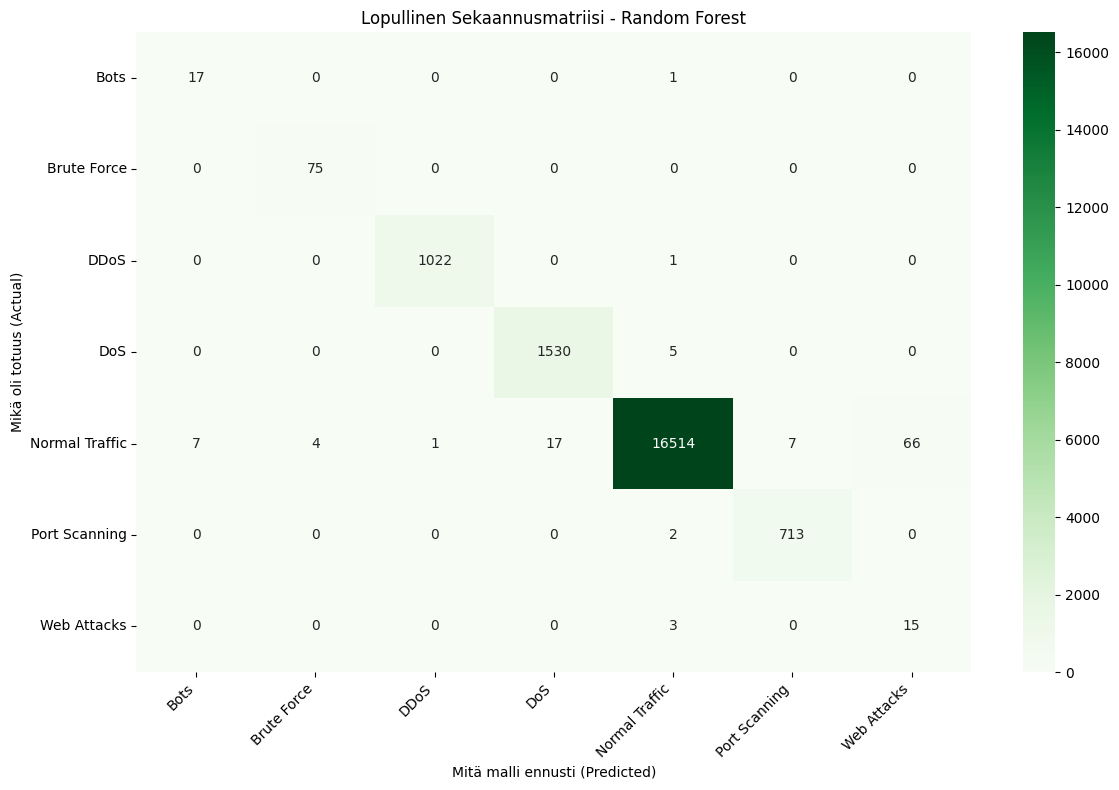

In [10]:
# --- RANDOM FOREST -OSUUS ALKAA TÄSTÄ ---

from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Rakennetaan lopullinen voittajaputki
final_pipeline_rf = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1))
])

# 2. Koulutetaan malli yhteisellä oppimisdatalla (X_train_full)
print("Koulutetaan Random Forest -mallia (tässä saattaa mennä hetki)...")
final_pipeline_rf.fit(X_train_full, y_train_full)

# 3. Tehdään ennusteet TESTIdatalla, jota malli ei ole KOSKAAN aiemmin nähnyt
y_test_pred_rf = final_pipeline_rf.predict(X_test)

# 4. Tulostetaan lopulliset tulokset
print("\n" + "="*50)
print("LOPULLISET TULOKSET (Random Forest) - TESTIDATA")
print("="*50)

print(f"\nLOPULLINEN TARKKUUS (Accuracy): {accuracy_score(y_test, y_test_pred_rf) * 100:.2f}%\n")
print("--- Luokitteluraportti (Classification Report) ---")
print(classification_report(y_test, y_test_pred_rf))

# 5. Piirretään sekaannusmatriisi
cm_final_rf = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(12, 8))
sns.heatmap(cm_final_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=final_pipeline_rf.classes_, 
            yticklabels=final_pipeline_rf.classes_)
plt.xlabel('Mitä malli ennusti (Predicted)')
plt.ylabel('Mikä oli totuus (Actual)')
plt.title('Lopullinen Sekaannusmatriisi - Random Forest')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- RANDOM FOREST -OSUUS PÄÄTTYY ---

In [ ]:
X = df.drop('Attack Type', axis=1)
# y = df['Attack Type']

# X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)